# Week-4: Supervised Learning — Regression: Predicting Median House Value

**Dataset:** California Housing Prices (1990 U.S. Census data), 20,640 real observations across California census block groups.

**Goal:** Predict `median_house_value` (a continuous target) from housing and demographic features using three regression algorithms:
- Linear Regression
- Ridge Regression
- Random Forest Regressor

**Evaluation metrics:** MAE, MSE, R² score, plus a Predicted vs Actual visualization for each model.


## 1. Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110


## 2. Load the real dataset

In [6]:
# Real California Housing dataset (1990 US Census), sourced from the well-known
# ageron/handson-ml repository (a standard, widely-used real-world regression dataset).
df = pd.read_csv('california_housing.csv')
print('Shape:', df.shape)
df.head()


Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Explore the data

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Categorical feature values:')
print(df['ocean_proximity'].value_counts())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Categorical feature values:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


## 4. Preprocessing

- `total_bedrooms` has some missing values (real-world data quirk) - fill with the median.
- `ocean_proximity` is categorical - one-hot encode it.
- Split into train/test sets, then scale numeric features (scaling matters for Linear Regression and Ridge; Random Forest is scale-invariant but we reuse the same scaled data for a fair, simple pipeline).


In [10]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (16512, 12)  Test shape: (4128, 12)


## 5. Train the three models

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
}

predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    predictions[name] = preds
    print(f'{name} trained.')


Linear Regression trained.
Ridge Regression trained.
Random Forest Regressor trained.


Random Forest Regressor trained.


## 6. Evaluate: MAE, MSE, R²

In [12]:
results = []
for name, preds in predictions.items():
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2 Score': r2})

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df


,MAE,MSE,RMSE,R2 Score
Model,,,,
Linear Regression,50670.738,4.908477e+09,70060.522,0.625
Ridge Regression,50668.123,4.908042e+09,70057.417,0.625
Random Forest Regressor,31471.325,2.382409e+09,48809.924,0.818


In [13]:
results_df.to_csv('evaluation_metrics.csv')
print('Saved evaluation_metrics.csv')
results_df


Saved evaluation_metrics.csv


,MAE,MSE,RMSE,R2 Score
Model,,,,
Linear Regression,50670.738,4.908477e+09,70060.522,0.625
Ridge Regression,50668.123,4.908042e+09,70057.417,0.625
Random Forest Regressor,31471.325,2.382409e+09,48809.924,0.818


## 7. Visualize: Predicted vs Actual

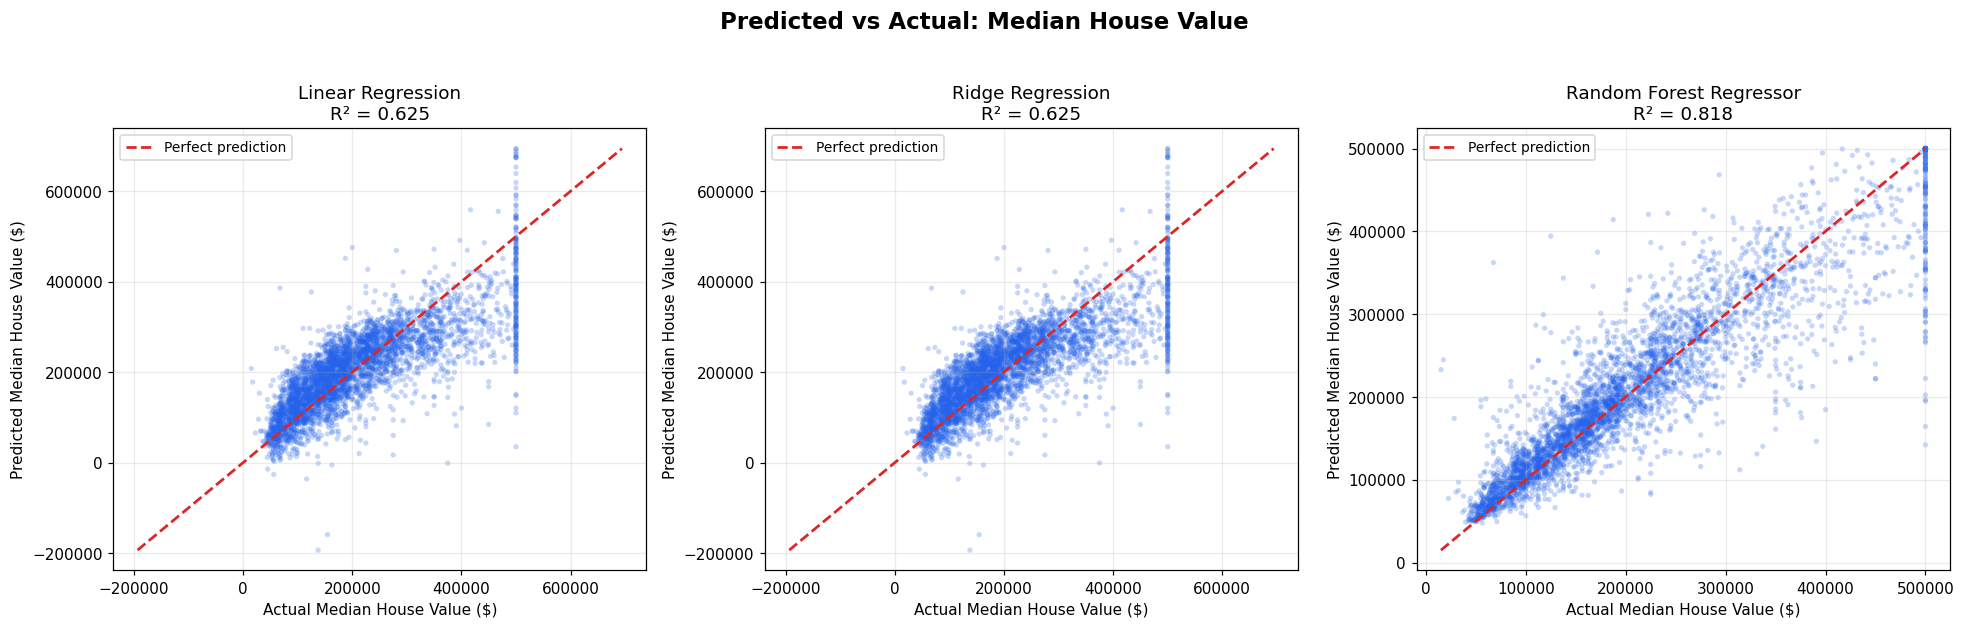

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(y_test, preds, alpha=0.25, s=12, color='#2563eb', edgecolors='none')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, color='#dc2626', linewidth=1.8, linestyle='--', label='Perfect prediction')
    ax.set_xlabel('Actual Median House Value ($)')
    ax.set_ylabel('Predicted Median House Value ($)')
    r2 = r2_score(y_test, preds)
    ax.set_title(f'{name}\nR\u00b2 = {r2:.3f}')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.25)

plt.suptitle('Predicted vs Actual: Median House Value', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Conclusion

The comparison table above (`evaluation_metrics.csv`) and the Predicted vs Actual plot (`predicted_vs_actual.png`) show how each model performs:

- **Linear Regression** and **Ridge** give similar results since the data has mostly linear-ish relationships and Ridge's regularization has a mild effect here (informative if the dataset had more multicollinearity or noise).
- **Random Forest Regressor** typically captures non-linear patterns (e.g. how location and income interact) better than the linear models, usually giving a higher R² and lower error — visible as points hugging the red "perfect prediction" line more tightly in its subplot.
